# Сравнение распределений квена и рандомного текста

За распределения берется среднее от софтмаксов логитов для квена и среднее векторов с одной единицей на месте реального токена для текста. 

Метрики сходства рапределений: JS-дивергенция и расстояние Хеллингера.

Нграмма: берется 20 токенов контекста и 21-й как таргет

In [ ]:
%pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import json
import os

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

In [3]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Загрузка модели {MODEL_NAME} на {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True
)
model.eval()
print("Модель загружена.")

Загрузка модели Qwen/Qwen3.5-0.8B-Base на cuda...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Модель загружена.


In [4]:
text = """Right now, I am studying Business Administration and Management program at the faculty of Economics. It lasts for 3 years, and when I finish it I will get a bachelor’s degree. After that, I am planning to apply for a master’s degree which is 2 more years. I study for this degree at the University of Pecs. It is a huge University with many campuses and dormitories. I am not a freshman; I am a sophomore. That is why I already know a lot of things about higher education. At the beginning of each semester, you have to enroll in your course. After that you register for the compulsory and optional subjects. You can choose from a great number of elective courses. You can do absolutely anything from yoga to programming If you choose to. After you finish your studies, you can calculate your GPA, it is the average of your marks during the semester. If you have it above 4, you can apply for different scholarships and grants.

Studying at the university is so much fun because you meet a lot of unique people. But do not think it is easy. Only the best graduates receive jobs at international companies, so take your time and study hard. During your education, it is a good idea to apply for different internships to get some valuable experience.

Overall, university is a nice place to be in, and I hope you will get to your dream university, and after that you will get your dream job."""

texts = [text]

In [5]:
def extract_token_ngrams(texts, tokenizer, n):
    ngrams = []
    
    for text in texts:
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        
        if len(token_ids) < n:
            continue
        
        for i in range(len(token_ids) - n):
            window_ids = token_ids[i:i + n]
        
            ngram_text = tokenizer.decode(window_ids, skip_special_tokens=True)
            ngrams.append(ngram_text)
    
    return ngrams

In [6]:
def get_distribution(model, tokenizer, prompts, batch_size=32):

    vocab_size = model.lm_head.out_features
    device = model.device

    total = 0

    accumulated_probs = torch.zeros(vocab_size, device=device)  # sum(p_i)

    for i in tqdm(range(0, len(prompts), batch_size), leave=False):
        batch_prompts = prompts[i:i + batch_size]
        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            logits = model(inputs.input_ids, attention_mask=inputs.attention_mask).logits

        # Берём логиты последнего реального токена каждой последовательности
        last_token_idx = inputs.attention_mask.sum(dim=1) - 1
        batch_logits = logits[torch.arange(logits.size(0)), last_token_idx]  # [B, V]

        # softmax для каждого примера
        probs = F.softmax(batch_logits, dim=-1)  # [B, V]

        # Накапливаем для mean(softmax) и var(softmax)
        accumulated_probs += probs.sum(dim=0)       # sum p_i

        total += len(batch_prompts)

    if total == 0:
        raise ValueError("Нет обработанных примеров.")
    # mean(softmax(logits))
    mean_probs = accumulated_probs / total
    dist_mean_of_softmax = mean_probs.cpu()

    return {
        "mean_of_softmax": dist_mean_of_softmax,
    }

In [7]:
torch.backends.cudnn.enabled = False  # обход бага Conv1D на некоторых GPU

In [8]:
N = 20
BATCH_SIZE = 32
SEED = 42

results = {
    "mean_of_softmax": {},   # mean(softmax(logits))
}


ngrams = extract_token_ngrams(texts, tokenizer, N+1) # N+1 потому что нам нужен таргет
print(f"  Н-грамм: {len(ngrams)}  |  пример: {repr(ngrams[0][:80])}")

if len(ngrams) == 0:
    print("  Пропускаем (нет данных)")

stats_model = get_distribution(model, tokenizer, ngrams, batch_size=BATCH_SIZE)

  Н-грамм: 275  |  пример: 'Right now, I am studying Business Administration and Management program at the f'


  0%|          | 0/9 [00:00<?, ?it/s]

In [9]:
def get_orig_distribution(tokenizer, prompts):
    vocab_size = model.lm_head.out_features

    accumulated_probs = torch.zeros(vocab_size)

    for prompt in prompts:
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding=True,
            truncation=True
        )
        
        last_token_idx = inputs.attention_mask.sum(dim=1) - 1
        accumulated_probs[inputs.input_ids[0][last_token_idx][0]] += 1

    mean_probs = accumulated_probs / len(prompts)

    return {
        "mean_of_softmax": mean_probs,
    }

In [10]:
stats_orig = get_orig_distribution(tokenizer, ngrams)

In [11]:
def compute_entropy(probs, eps=1e-10):
    p = torch.clamp(probs, min=eps)
    p = p / p.sum()
    return (-torch.sum(p * torch.log2(p))).item()


def compute_perplexity(probs, eps=1e-10):
    return 2 ** compute_entropy(probs, eps)


def compute_helinger(probs1, probs2, eps=1e-10):
    p1 = torch.clamp(probs1, min=eps)
    p1 = p1 / p1.sum()
    
    p2 = torch.clamp(probs2, min=eps)
    p2 = p2 / p2.sum()
    
    bc_coeff = torch.sum(torch.sqrt(p1 * p2))
    return torch.sqrt(torch.clamp(1.0 - bc_coeff, min=0.0)).item()


def compute_kld(probs1, probs2, eps=1e-10):
    p1 = torch.clamp(probs1, min=eps)
    p1 = p1 / p1.sum()

    p2 = torch.clamp(probs2, min=eps)
    p2 = p2 / p2.sum()
    
    return torch.sum(p1 * torch.log2(p1 / p2)).item()


def compute_jsd(probs1, probs2, eps=1e-10):
    p1 = torch.clamp(probs1, min=eps)
    p1 = p1 / p1.sum()

    p2 = torch.clamp(probs2, min=eps)
    p2 = p2 / p2.sum()

    pm = 0.5 * (p1 + p2)
    
    kld1 = torch.sum(p1 * torch.log2(p1 / pm))
    kld2 = torch.sum(p2 * torch.log2(p2 / pm))
    
    return (0.5 * (kld1 + kld2)).item()

In [12]:
stats_model = stats_model["mean_of_softmax"]
stats_orig = stats_orig["mean_of_softmax"]

In [13]:
helinger = compute_helinger(stats_model, stats_orig)

kld_mo = compute_kld(stats_model, stats_orig)

kld_om = compute_kld(stats_orig, stats_model)

jsd = compute_jsd(stats_model, stats_orig)

In [14]:
print("helinger ", helinger)
print("kld_mo ", kld_mo)
print("kld_om ", kld_om)
print("jsd ", jsd)

helinger  0.541684091091156
kld_mo  8.723254203796387
kld_om  1.3861041069030762
jsd  0.3196672201156616


## Вариант 1: Rank реального токена
Насколько высоко модель ставит правильный следующий токен среди всего словаря.

In [15]:
def get_token_ranks(model, tokenizer, prompts, batch_size=32):
    """
    Для каждого промпта:
      - предсказываем распределение на следующий токен
      - находим rank реального следующего токена (1 = лучший)
      - записываем rank и его вероятность
    
    prompts — список n-грамм длины N+1; последний токен = таргет.
    """
    device = model.device
    ranks = []
    target_probs = []

    for i in tqdm(range(0, len(prompts), batch_size), leave=False):
        batch = prompts[i:i + batch_size]

        # Кодируем всю n-грамму
        enc_full = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)

        # Таргет — последний реальный токен каждой последовательности
        seq_lens = enc_full.attention_mask.sum(dim=1)          # [B]
        target_ids = enc_full.input_ids[
            torch.arange(len(batch)), seq_lens - 1
        ]  # [B]

        # Контекст = всё кроме последнего токена
        ctx_ids  = enc_full.input_ids[:, :-1]
        ctx_mask = enc_full.attention_mask[:, :-1]

        with torch.no_grad():
            logits = model(ctx_ids, attention_mask=ctx_mask).logits  # [B, L-1, V]

        # Берём логиты позиции, предшествующей таргету
        ctx_lens = ctx_mask.sum(dim=1) - 1                          # [B]
        pred_logits = logits[torch.arange(len(batch)), ctx_lens]    # [B, V]

        probs = F.softmax(pred_logits, dim=-1)                      # [B, V]

        # Rank = количество токенов с prob >= prob(target) + 1
        target_p = probs[torch.arange(len(batch)), target_ids]      # [B]
        rank = (probs >= target_p.unsqueeze(1)).sum(dim=1)          # [B]

        ranks.extend(rank.cpu().tolist())
        target_probs.extend(target_p.cpu().tolist())

    return {
        "ranks": ranks,
        "target_probs": target_probs,
    }

In [16]:
rank_stats = get_token_ranks(model, tokenizer, ngrams, batch_size=BATCH_SIZE)

ranks       = rank_stats["ranks"]
target_probs = rank_stats["target_probs"]

print(f"Медиана rank:        {np.median(ranks):.0f}")
print(f"Средний rank:        {np.mean(ranks):.1f}")
print(f"% rank == 1 (top-1): {np.mean(np.array(ranks) == 1)*100:.1f}%")
print(f"% rank <= 5:         {np.mean(np.array(ranks) <= 5)*100:.1f}%")
print(f"% rank <= 10:        {np.mean(np.array(ranks) <= 10)*100:.1f}%")
print(f"Средняя prob target: {np.mean(target_probs):.4f}")

  0%|          | 0/9 [00:00<?, ?it/s]

Медиана rank:        2
Средний rank:        38.3
% rank == 1 (top-1): 39.6%
% rank <= 5:         69.5%
% rank <= 10:        77.5%
Средняя prob target: 0.2366


## Вариант 2: Per-token cross-entropy и Perplexity

In [17]:
def get_perplexity(model, tokenizer, prompts, batch_size=32):
    """
    Считает per-token cross-entropy и perplexity.
    CE = -log2 p(target | context)  для каждого промпта.
    PPL = 2^(mean CE).
    """
    device = model.device
    ce_list = []

    for i in tqdm(range(0, len(prompts), batch_size), leave=False):
        batch = prompts[i:i + batch_size]

        enc_full = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
        seq_lens = enc_full.attention_mask.sum(dim=1)
        target_ids = enc_full.input_ids[
            torch.arange(len(batch)), seq_lens - 1
        ]  # [B]

        ctx_ids  = enc_full.input_ids[:, :-1]
        ctx_mask = enc_full.attention_mask[:, :-1]

        with torch.no_grad():
            logits = model(ctx_ids, attention_mask=ctx_mask).logits

        ctx_lens = ctx_mask.sum(dim=1) - 1
        pred_logits = logits[torch.arange(len(batch)), ctx_lens]   # [B, V]

        # cross-entropy = -log2 p(target)
        log_probs = F.log_softmax(pred_logits, dim=-1)             # [B, V], натуральный log
        target_log_p = log_probs[torch.arange(len(batch)), target_ids]  # [B]
        ce_bits = -target_log_p / np.log(2)                         # переводим в биты

        ce_list.extend(ce_bits.cpu().tolist())

    mean_ce = np.mean(ce_list)
    ppl     = 2 ** mean_ce

    return {
        "ce_per_token": ce_list,
        "mean_ce_bits": mean_ce,
        "perplexity":   ppl,
    }

In [18]:
ppl_stats = get_perplexity(model, tokenizer, ngrams, batch_size=BATCH_SIZE)

print(f"Mean cross-entropy (bits): {ppl_stats['mean_ce_bits']:.3f}")
print(f"Perplexity:                {ppl_stats['perplexity']:.2f}")

  0%|          | 0/9 [00:00<?, ?it/s]

Mean cross-entropy (bits): 4.019
Perplexity:                16.21


## Top-p (nucleus) фильтрация p=0.9

Проверяем, попадает ли реальный токен в nucleus (top-p = 0.9) и считаем размер ядра.

In [19]:
def apply_top_p(probs: torch.Tensor, top_p: float = 0.9):
    """
    Возвращает маску токенов, входящих в nucleus top-p.
    probs: [B, V] — softmax-вероятности
    Возвращает:
      nucleus_mask:  [B, V] bool
      nucleus_sizes: [B]    int  — количество токенов в ядре
    """
    sorted_probs, sorted_idx = torch.sort(probs, dim=-1, descending=True)  # [B, V]
    cumsum = torch.cumsum(sorted_probs, dim=-1)                            # [B, V]

    # Токены, у которых накопленная сумма <= top_p (сдвигаем на 1, чтобы включить пороговый)
    in_nucleus = cumsum - sorted_probs < top_p                             # [B, V]

    # Восстанавливаем исходный порядок
    nucleus_mask = torch.zeros_like(probs, dtype=torch.bool)
    nucleus_mask.scatter_(1, sorted_idx, in_nucleus)

    nucleus_sizes = in_nucleus.sum(dim=-1)                                 # [B]
    return nucleus_mask, nucleus_sizes


def get_top_p_stats(model, tokenizer, prompts, top_p=0.9, batch_size=32):
    """
    Для каждого промпта проверяет:
      - входит ли реальный токен в nucleus top-p
      - какой размер nucleus (сколько токенов в нём)
    """
    device = model.device
    in_nucleus_list  = []
    nucleus_size_list = []

    for i in tqdm(range(0, len(prompts), batch_size), leave=False):
        batch = prompts[i:i + batch_size]

        enc_full = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
        seq_lens = enc_full.attention_mask.sum(dim=1)
        target_ids = enc_full.input_ids[
            torch.arange(len(batch)), seq_lens - 1
        ]  # [B]

        ctx_ids  = enc_full.input_ids[:, :-1]
        ctx_mask = enc_full.attention_mask[:, :-1]

        with torch.no_grad():
            logits = model(ctx_ids, attention_mask=ctx_mask).logits

        ctx_lens = ctx_mask.sum(dim=1) - 1
        pred_logits = logits[torch.arange(len(batch)), ctx_lens]  # [B, V]
        probs = F.softmax(pred_logits, dim=-1)                    # [B, V]

        nucleus_mask, nucleus_sizes = apply_top_p(probs, top_p=top_p)

        # Проверяем, входит ли таргет в nucleus
        target_in = nucleus_mask[torch.arange(len(batch)), target_ids]  # [B] bool

        in_nucleus_list.extend(target_in.cpu().tolist())
        nucleus_size_list.extend(nucleus_sizes.cpu().tolist())

    return {
        "in_nucleus":    in_nucleus_list,
        "nucleus_sizes": nucleus_size_list,
    }

In [20]:
TOP_P = 0.9
top_p_stats = get_top_p_stats(model, tokenizer, ngrams, top_p=TOP_P, batch_size=BATCH_SIZE)

in_nuc   = np.array(top_p_stats["in_nucleus"])
nuc_size = np.array(top_p_stats["nucleus_sizes"])

print(f"Top-p = {TOP_P}")
print(f"% токенов внутри nucleus:   {in_nuc.mean()*100:.1f}%")
print(f"Средний размер nucleus:     {nuc_size.mean():.1f} токенов")
print(f"Медианный размер nucleus:   {np.median(nuc_size):.0f} токенов")

  0%|          | 0/9 [00:00<?, ?it/s]

Top-p = 0.9
% токенов внутри nucleus:   94.2%
Средний размер nucleus:     142.3 токенов
Медианный размер nucleus:   48 токенов


## Визуализация: все метрики вместе

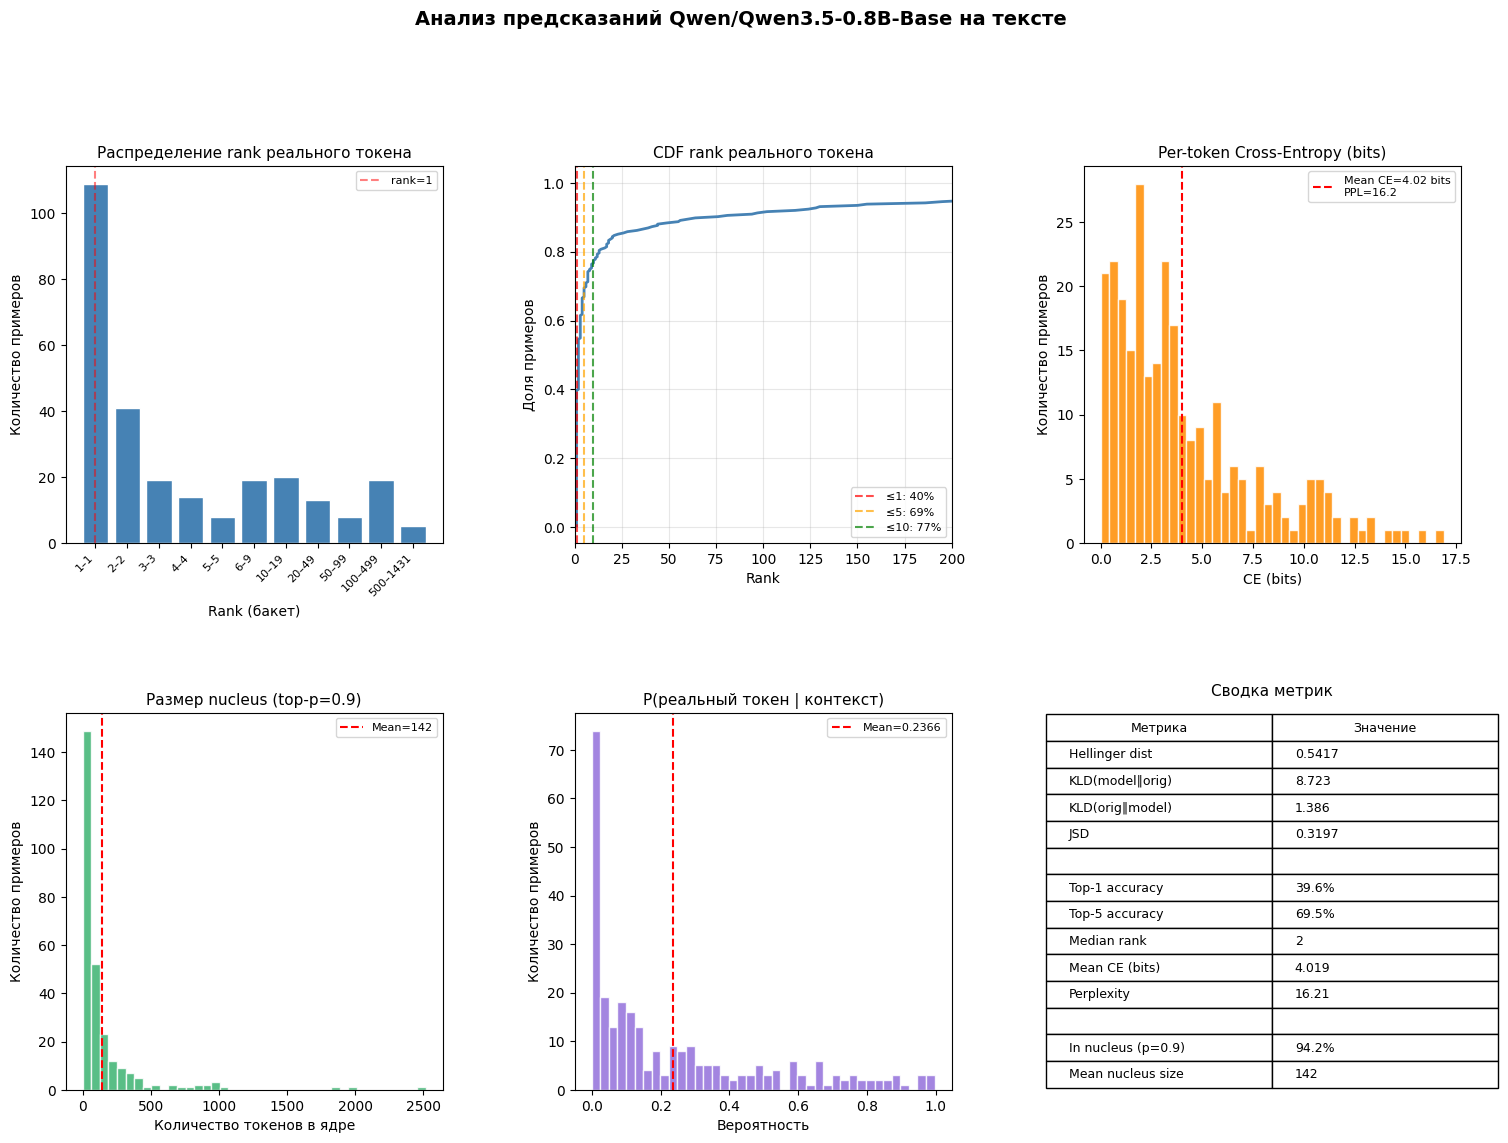

Сохранено: metrics_summary.png


In [21]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Распределение ranks ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
rank_arr = np.array(ranks)
bins = [1, 2, 3, 4, 5, 6, 10, 20, 50, 100, 500, rank_arr.max() + 1]
counts, edges = np.histogram(rank_arr, bins=bins)
labels = [f"{int(edges[i])}–{int(edges[i+1])-1}" for i in range(len(counts))]
ax1.bar(range(len(counts)), counts, color="steelblue", edgecolor="white")
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax1.set_title("Распределение rank реального токена", fontsize=11)
ax1.set_xlabel("Rank (бакет)")
ax1.set_ylabel("Количество примеров")
ax1.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="rank=1")
ax1.legend(fontsize=8)

# ── 2. CDF ranks ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sorted_ranks = np.sort(rank_arr)
cdf = np.arange(1, len(sorted_ranks) + 1) / len(sorted_ranks)
ax2.plot(sorted_ranks, cdf, color="steelblue", linewidth=2)
for thr, col in [(1, "red"), (5, "orange"), (10, "green")]:
    val = np.mean(rank_arr <= thr)
    ax2.axvline(thr, color=col, linestyle="--", alpha=0.7, label=f"≤{thr}: {val*100:.0f}%")
ax2.set_xlim(0, min(200, sorted_ranks.max()))
ax2.set_title("CDF rank реального токена", fontsize=11)
ax2.set_xlabel("Rank")
ax2.set_ylabel("Доля примеров")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Cross-entropy по токенам ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ce_arr = np.array(ppl_stats["ce_per_token"])
ax3.hist(ce_arr, bins=40, color="darkorange", edgecolor="white", alpha=0.85)
ax3.axvline(ppl_stats["mean_ce_bits"], color="red", linestyle="--",
            label=f"Mean CE={ppl_stats['mean_ce_bits']:.2f} bits\nPPL={ppl_stats['perplexity']:.1f}")
ax3.set_title("Per-token Cross-Entropy (bits)", fontsize=11)
ax3.set_xlabel("CE (bits)")
ax3.set_ylabel("Количество примеров")
ax3.legend(fontsize=8)

# ── 4. Размер nucleus top-p=0.9 ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(nuc_size, bins=40, color="mediumseagreen", edgecolor="white", alpha=0.85)
ax4.axvline(nuc_size.mean(), color="red", linestyle="--",
            label=f"Mean={nuc_size.mean():.0f}")
ax4.set_title(f"Размер nucleus (top-p={TOP_P})", fontsize=11)
ax4.set_xlabel("Количество токенов в ядре")
ax4.set_ylabel("Количество примеров")
ax4.legend(fontsize=8)

# ── 5. Вероятность реального токена ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
tp_arr = np.array(target_probs)
ax5.hist(tp_arr, bins=40, color="mediumpurple", edgecolor="white", alpha=0.85)
ax5.axvline(tp_arr.mean(), color="red", linestyle="--",
            label=f"Mean={tp_arr.mean():.4f}")
ax5.set_title("P(реальный токен | контекст)", fontsize=11)
ax5.set_xlabel("Вероятность")
ax5.set_ylabel("Количество примеров")
ax5.legend(fontsize=8)

# ── 6. Сводная таблица метрик ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary = [
    ["Метрика", "Значение"],
    ["Hellinger dist",       f"{helinger:.4f}"],
    ["KLD(model‖orig)",      f"{kld_mo:.3f}"],
    ["KLD(orig‖model)",      f"{kld_om:.3f}"],
    ["JSD",                  f"{jsd:.4f}"],
    ["", ""],
    ["Top-1 accuracy",       f"{np.mean(rank_arr==1)*100:.1f}%"],
    ["Top-5 accuracy",       f"{np.mean(rank_arr<=5)*100:.1f}%"],
    ["Median rank",          f"{np.median(rank_arr):.0f}"],
    ["Mean CE (bits)",       f"{ppl_stats['mean_ce_bits']:.3f}"],
    ["Perplexity",           f"{ppl_stats['perplexity']:.2f}"],
    ["", ""],
    [f"In nucleus (p={TOP_P})", f"{in_nuc.mean()*100:.1f}%"],
    ["Mean nucleus size",    f"{nuc_size.mean():.0f}"],
]
tbl = ax6.table(cellText=summary[1:], colLabels=summary[0],
                loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
ax6.set_title("Сводка метрик", fontsize=11, pad=12)

fig.suptitle(f"Анализ предсказаний {MODEL_NAME} на тексте", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: metrics_summary.png")